<a href="https://colab.research.google.com/github/2403a52208-sudo/NLP/blob/main/2403A52208_B09_Assg10_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install

In [5]:
!pip install gensim

import libraries





In [11]:
# Loading Pre-trained Embeddings
from gensim.models import KeyedVectors
import gensim.downloader as api
# Handling Matrices & Numerical Operations
import numpy as np
# Visualization
import matplotlib.pyplot as plt
# t-SNE for Dimensionality Reduction
from sklearn.manifold import TSNE

 Load pre-trained Word2Vec model....

In [13]:
model_word2vec = api.load("word2vec-google-news-300")
model_glove = api.load("glove-wiki-gigaword-100")

In [14]:
word_list = [
    # Sports
    "football", "basketball", "tennis", "cricket", "swimming",

    # Food
    "pizza", "burger", "pasta", "sushi", "salad",

    # Colors
    "red", "blue", "green", "yellow", "purple",

    # Professions
    "engineer", "artist", "scientist", "pilot", "chef",

    # Space
    "planet", "star", "galaxy", "moon", "asteroid",

    # Music
    "guitar", "piano", "drums", "violin", "singer",

    # Emotions
    "happy", "sad", "angry", "excited", "calm",

    # Weather
    "rain", "snow", "wind", "storm", "sunshine"
]

In [15]:
vectors = [model_word2vec[word] for word in word_list if word in model_word2vec]

# Convert to NumPy array
vectors_word2vec = np.array(vectors)

print("Total selected words:", len(word_list))
print("Vector shape:", vectors_word2vec.shape)
print(vectors_word2vec[0])


Total selected words: 40
Vector shape: (40, 300)
[-9.76562500e-02  3.19824219e-02  2.57812500e-01 -4.15039062e-02
  1.01562500e-01 -1.00585938e-01  1.46484375e-01 -1.99218750e-01
  1.53320312e-01  6.34765625e-02  8.39843750e-02 -3.00781250e-01
  6.34765625e-02  2.08984375e-01 -2.11914062e-01  1.88476562e-01
 -8.34960938e-02  3.28125000e-01  2.79296875e-01 -1.40625000e-01
 -1.68945312e-01  2.04101562e-01  4.90722656e-02 -6.98852539e-03
  9.42382812e-02  9.84191895e-04  3.12500000e-02  2.48046875e-01
  3.35937500e-01  2.63671875e-01  5.68847656e-02  3.04687500e-01
  1.21582031e-01 -1.97265625e-01  1.72119141e-02  9.96093750e-02
  2.27539062e-01 -1.20605469e-01  1.23535156e-01  3.78906250e-01
  2.36816406e-02 -1.86523438e-01  6.29882812e-02  1.52343750e-01
  3.73535156e-02 -1.69921875e-01  1.06445312e-01 -4.98046875e-02
 -6.20117188e-02  1.68945312e-01  4.41894531e-02  2.78320312e-02
 -1.10839844e-01  4.49218750e-02  2.78320312e-02 -4.45312500e-01
  3.49121094e-02 -6.22558594e-02 -3.93066

Load TSNE model

In [16]:
vectors = [model_glove[word] for word in word_list if word in model_glove]

# Convert to NumPy array
vectors_glove = np.array(vectors)

print("Total selected words:", len(word_list))
print("Vector shape:", vectors_glove.shape)
print(vectors_glove[0])

Total selected words: 40
Vector shape: (40, 100)
[ 0.43865    0.10537    0.45972   -1.0724    -1.2471     0.76351
  0.47528    0.083857  -0.9127    -0.27328   -0.018591  -1.184
  0.22748    0.16847   -0.52158    0.11339    1.3757     0.11892
 -0.37683    0.51149   -0.8833     0.96259    0.18143   -0.407
  0.036181  -0.74432   -0.0027401 -0.70068    0.53103    0.45114
 -0.72884    1.0631    -0.28008   -0.63848    0.15645   -0.46927
 -1.0071     1.033     -1.4354    -0.27485    0.048984   0.13951
  0.43072   -0.78791    0.41097    0.58509    1.0155    -0.1839
  0.27487   -0.90866   -0.30441   -0.17396    0.020941   0.62813
  0.10978   -2.3885    -0.56364   -0.27193    0.98728    0.70608
 -0.512      0.52636   -0.78503   -0.68714    0.38121    0.097582
 -0.20237    0.43208   -0.30527    0.57925    0.62619   -0.47415
  0.33834   -0.28421   -0.097465   0.19597    0.54849    0.59918
 -0.41576    0.1021     0.6766     0.0042009 -0.12354   -0.76613
 -0.27436   -0.68248   -1.0789    -0.16708   

In [17]:
# Assume vectors already extracted from previous step
# vectors shape example: (40, 100)

# Apply t-SNE
tsne = TSNE(
    n_components=2,      # Reduce to 2D
    random_state=42,
    perplexity=10,
    learning_rate=200
)

tsne_coordinates = tsne.fit_transform(vectors_word2vec)

# Store results
print("Original Shape:", vectors_word2vec.shape)
print("Reduced Shape:", tsne_coordinates.shape)

# Display first 5 coordinates
print("\nFirst 5 t-SNE Coordinates:")
print(tsne_coordinates[:5])
# Display first 5 coordinates of word2vec
print("\nFirst 5 t-SNE Coordinates:")
print(vectors_word2vec[:5])

Original Shape: (40, 300)
Reduced Shape: (40, 2)

First 5 t-SNE Coordinates:
[[-34.212677 -46.742313]
 [-44.309284 -38.047806]
 [-55.728962 -47.723877]
 [-41.207836 -66.578476]
 [-64.14059  -29.555346]]

First 5 t-SNE Coordinates:
[[-0.09765625  0.03198242  0.2578125  ...  0.00201416 -0.12158203
   0.15820312]
 [-0.00854492  0.08447266  0.21289062 ...  0.22167969  0.04663086
   0.25976562]
 [-0.2890625  -0.08642578  0.23144531 ...  0.13964844 -0.18066406
   0.08154297]
 [-0.3671875  -0.12158203  0.28515625 ...  0.24902344 -0.14257812
   0.04150391]
 [-0.11230469  0.2734375   0.22558594 ...  0.06640625  0.07568359
   0.02758789]]


Plot

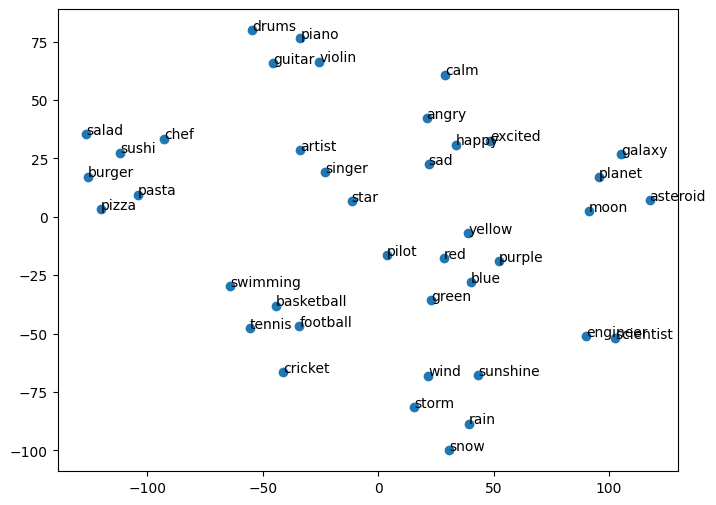

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(tsne_coordinates[:,0], tsne_coordinates[:,1])

for i, word in enumerate(word_list):
    plt.annotate(word, (tsne_coordinates[i,0], tsne_coordinates[i,1]))

plt.show()

Load TSNE & reduce dim in glove

In [19]:
# Assume vectors already extracted from previous step
# vectors shape example: (40, 100)

# Apply t-SNE
tsne = TSNE(
    n_components=2,      # Reduce to 2D
    random_state=42,
    perplexity=10,
    learning_rate=200
)

tsne_coordinates = tsne.fit_transform(vectors_glove)

# Store results
print("Original Shape:", vectors_glove.shape)
print("Reduced Shape:", tsne_coordinates.shape)

# Display first 5 coordinates
print("\nFirst 5 t-SNE Coordinates:")
print(tsne_coordinates[:5])
# Display first 5 coordinates of glove
print("\nFirst 5 t-SNE Coordinates:")
print(vectors_glove[:5])

Original Shape: (40, 100)
Reduced Shape: (40, 2)

First 5 t-SNE Coordinates:
[[ 85.53802  132.40034 ]
 [ 66.252655 140.14983 ]
 [ 71.0493   171.03598 ]
 [109.11246  145.98962 ]
 [ 47.785793 172.7015  ]]

First 5 t-SNE Coordinates:
[[ 4.3865e-01  1.0537e-01  4.5972e-01 -1.0724e+00 -1.2471e+00  7.6351e-01
   4.7528e-01  8.3857e-02 -9.1270e-01 -2.7328e-01 -1.8591e-02 -1.1840e+00
   2.2748e-01  1.6847e-01 -5.2158e-01  1.1339e-01  1.3757e+00  1.1892e-01
  -3.7683e-01  5.1149e-01 -8.8330e-01  9.6259e-01  1.8143e-01 -4.0700e-01
   3.6181e-02 -7.4432e-01 -2.7401e-03 -7.0068e-01  5.3103e-01  4.5114e-01
  -7.2884e-01  1.0631e+00 -2.8008e-01 -6.3848e-01  1.5645e-01 -4.6927e-01
  -1.0071e+00  1.0330e+00 -1.4354e+00 -2.7485e-01  4.8984e-02  1.3951e-01
   4.3072e-01 -7.8791e-01  4.1097e-01  5.8509e-01  1.0155e+00 -1.8390e-01
   2.7487e-01 -9.0866e-01 -3.0441e-01 -1.7396e-01  2.0941e-02  6.2813e-01
   1.0978e-01 -2.3885e+00 -5.6364e-01 -2.7193e-01  9.8728e-01  7.0608e-01
  -5.1200e-01  5.2636e-01 -7.

Plot

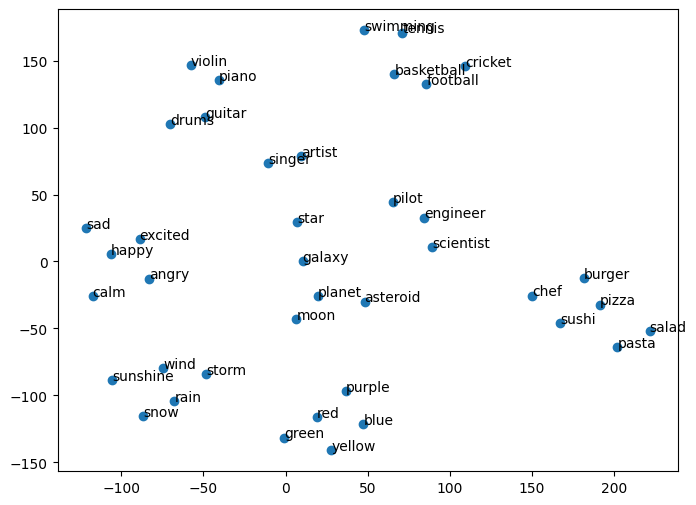

In [20]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(tsne_coordinates[:,0], tsne_coordinates[:,1])

for i, word in enumerate(word_list):
    plt.annotate(word, (tsne_coordinates[i,0], tsne_coordinates[i,1]))

plt.show()